In [4]:
# Core data science and plotting libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Scikit-learn modules grouped by purpose
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


In [5]:
df = pd.read_csv('../data/regresja/domy.csv',na_values=["?","NA",""])
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,'Wd Sdng','Wd Shng',NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
print("Shape of dataframe:", df.shape)

Shape of dataframe: (1460, 81)


In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

### Usunięcie outlierów
Usunięcie outlierów zgodne z rekomendacjami autora

In [8]:
df = df[df['GrLivArea'] <= 4000]

### Handlowanie braków danych

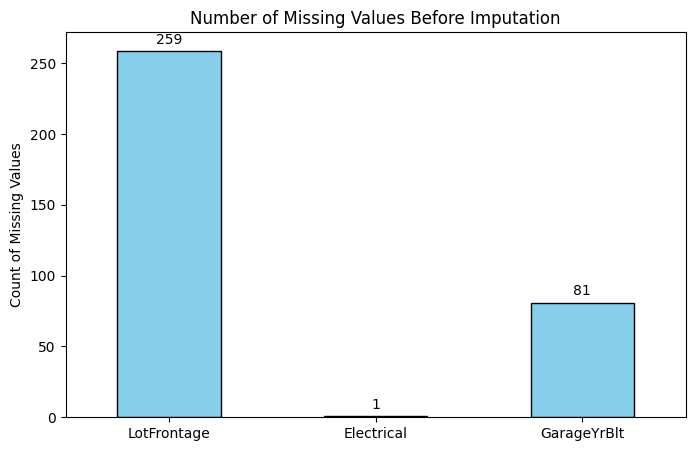

Maximum missing values in any column after cleaning: 0


In [9]:
# Categorical features where NaN means "None" (Feature does not exist)
cols_na_means_none = [
    'Alley', 'PoolQC', 'MiscFeature', 'Fence', 'FireplaceQu', 
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 
    'MasVnrType'
]

for col in cols_na_means_none:
    df[col] = df[col].fillna('None')

# Numerical features where NaN means "0" (Feature does not exist)
cols_na_means_zero = [
    'GarageArea', 'GarageCars', 
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]

for col in cols_na_means_zero:
    df[col] = df[col].fillna(0)

# Counting and drawing the gaps before filling them in
missing_columns = ['LotFrontage', 'Electrical', 'GarageYrBlt']
missing_counts = df[missing_columns].isnull().sum()

plt.figure(figsize=(8, 5))
ax = missing_counts.plot(kind='bar', color='skyblue', edgecolor='black')

ax.bar_label(ax.containers[0], padding=3)
plt.title('Number of Missing Values Before Imputation')
plt.ylabel('Count of Missing Values')
plt.xticks(rotation=0)
plt.show()

# Truly missing numerical data LotFrontage
df['LotFrontage'] = df['LotFrontage'].fillna(
    df.groupby('Neighborhood')['LotFrontage'].transform('median')
)

# Truly missing Electrical data
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

# Fill missing Garage Year Built with the Year the house was built
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])

# Verify that all missing values have been handled
remaining_nulls = df.isnull().sum().max()
print(f"Maximum missing values in any column after cleaning: {remaining_nulls}")

In [10]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.00000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000
mean,729.967033,56.888736,69.895948,10448.784341,6.088599,5.576236,1971.18544,1984.819368,101.526786,436.991071,46.677198,566.990385,1050.658654,1157.108516,343.532967,5.860577,1506.502060,0.423764,0.057005,1.561813,0.381181,2.864698,1.046703,6.506181,0.609203,1976.439560,1.764423,471.568681,93.833791,46.221154,22.014423,3.418956,15.102335,2.055632,43.608516,6.326236,2007.817308,180151.233516
std,421.722909,42.358363,21.331035,9860.763449,1.369669,1.113966,30.20159,20.652143,177.011773,430.255052,161.522376,442.197182,412.155715,369.307331,431.528915,48.688904,496.815378,0.517420,0.237786,0.547683,0.502533,0.815800,0.220627,1.611800,0.640359,26.308749,0.746215,211.986421,125.192349,65.352424,61.192248,29.357056,55.828405,35.383772,496.799265,2.698356,1.329394,76696.592530
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.00000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1872.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,364.750000,20.000000,60.000000,7538.750000,5.000000,5.000000,1954.00000,1966.750000,0.000000,0.000000,0.000000,222.500000,795.000000,882.000000,0.000000,0.000000,1128.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1959.000000,1.000000,329.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129900.000000
50%,730.500000,50.000000,70.000000,9468.500000,6.000000,5.000000,1972.00000,1993.500000,0.000000,381.000000,0.000000,477.500000,990.500000,1086.000000,0.000000,0.000000,1458.500000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1978.000000,2.000000,478.500000,0.000000,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1094.250000,70.000000,80.000000,11588.000000,7.000000,6.000000,2000.00000,2004.000000,163.250000,706.500000,0.000000,808.000000,1293.750000,1389.250000,728.000000,0.000000,1775.250000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2001.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.00000,2010.000000,1600.000000,2188.000000,1474.000000,2336.000000,3206.000000,3228.000000,1818.000000,572.000000,3627.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1390.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,625000.000000


In [11]:
df['SalePrice'].describe()

count      1456.000000
mean     180151.233516
std       76696.592530
min       34900.000000
25%      129900.000000
50%      163000.000000
75%      214000.000000
max      625000.000000
Name: SalePrice, dtype: float64

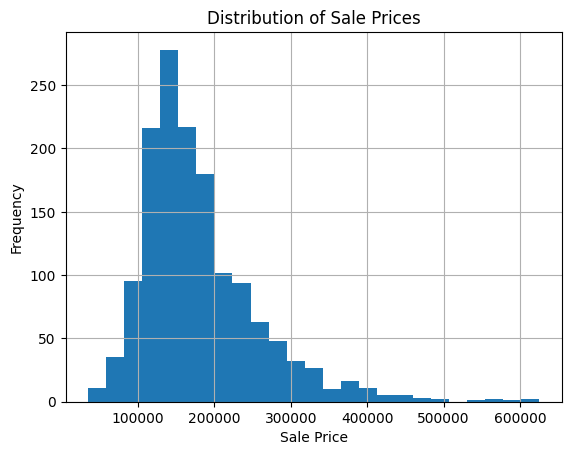

In [12]:
df['SalePrice'].hist(bins=25)
plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.title('Distribution of Sale Prices')
plt.show()

### Sprawdzanie czy istnieją kolumny stałe albo prawie stałe 

In [13]:
constant_cols = []
near_constant_rows = []
id_like_cols = []

near_constant_threshold = 0.95

for col in df.columns:
    unique_count = df[col].nunique(dropna=True)

    if unique_count <= 1:
        constant_cols.append(col)
        continue

    value_distribution = df[col].value_counts(normalize=True, dropna=False)
    top_frequency = value_distribution.iloc[0]
    top_value = value_distribution.index[0]

    if top_frequency >= near_constant_threshold:
        near_constant_rows.append({
            "column": col,
            "top_value": "NaN" if pd.isna(top_value) else top_value,
            "top_frequency": top_frequency,
            "unique_values": unique_count,
            "missing_values": df[col].isnull().sum(),
            "dtype": str(df[col].dtype)
        })

    if unique_count == len(df):
        id_like_cols.append(col)

near_constant_df = pd.DataFrame(near_constant_rows).sort_values(
    by="top_frequency", ascending=False
).reset_index(drop=True)

constant_df = pd.DataFrame({"column": constant_cols})
id_like_df = pd.DataFrame({"column": id_like_cols})

print("Constant columns:")
display(constant_df if not constant_df.empty else "Empty")

print(f"Near-constant columns ({near_constant_threshold*100:.0f}% or more of the same value):")
display(near_constant_df if not near_constant_df.empty else "Empty")

print("Potential ID-like columns:")
display(id_like_df if not id_like_df.empty else "Empty")

Constant columns:


'Empty'

Near-constant columns (95% or more of the same value):


,column,top_value,top_frequency,unique_values,missing_values,dtype
0,Utilities,AllPub,0.999313,2,0,str
1,PoolQC,None,0.996566,4,0,str
2,PoolArea,0,0.996566,6,0,int64
3,Street,Pave,0.995879,2,0,str
4,Condition2,Norm,0.990385,8,0,str
5,RoofMatl,CompShg,0.983516,7,0,str
6,3SsnPorch,0,0.983516,20,0,int64
7,LowQualFinSF,0,0.982143,24,0,int64
8,Heating,GasA,0.978022,6,0,str
9,MiscVal,0,0.964286,21,0,int64


Potential ID-like columns:


,column
0,Id


# Badanie skorelowania kolumn

### Heatmapa korelacji dla najwazniejszych cech numerycznych

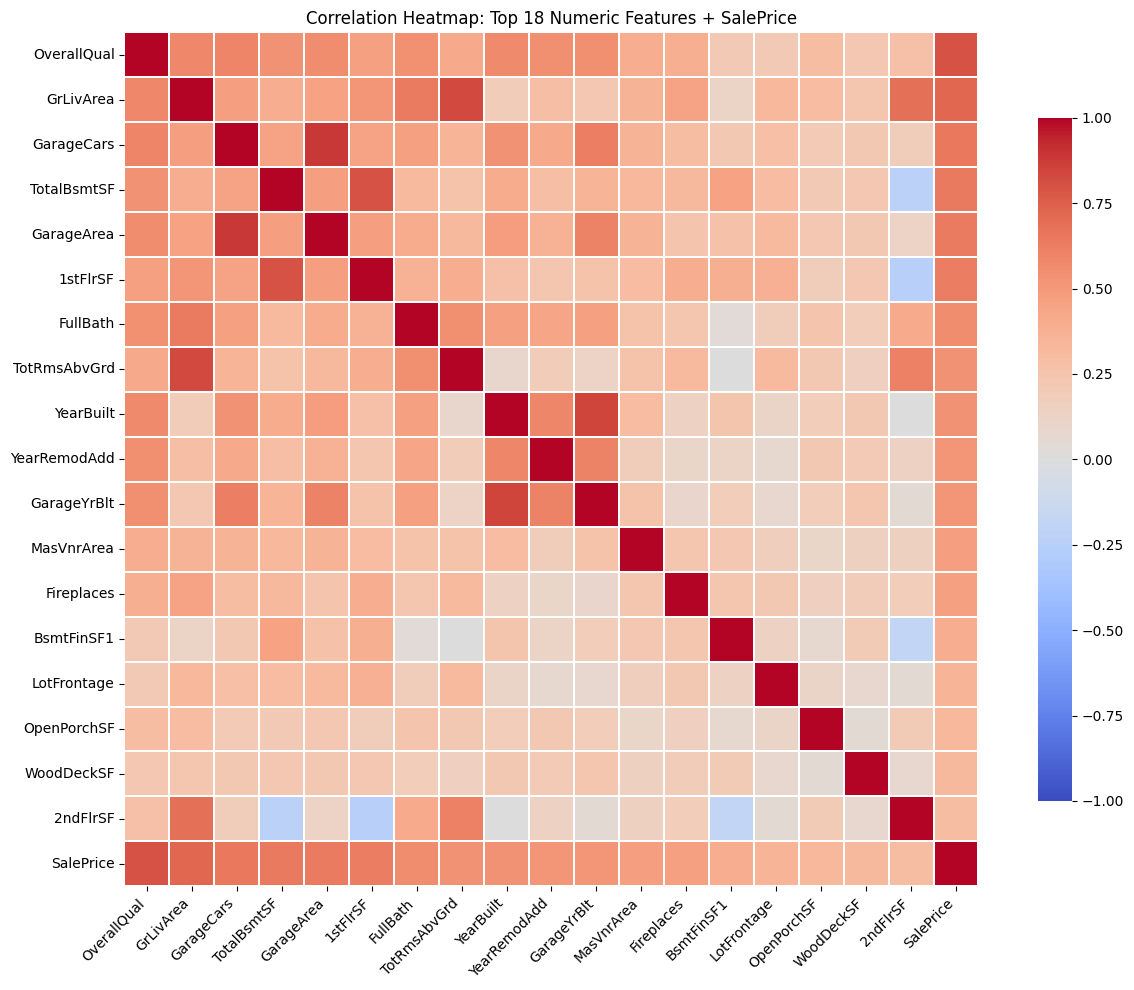

In [14]:
import seaborn as sns

top_n = 18
top_corr_features = (
    df.corr(numeric_only=True)['SalePrice']
    .abs()
    .sort_values(ascending=False)
    .drop('SalePrice')
    .head(top_n)
    .index
    .tolist()
 )

heatmap_cols = top_corr_features + ['SalePrice']
heatmap_data = df[heatmap_cols].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(
    heatmap_data,
    annot=False,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.3,
    cbar_kws={'shrink': 0.8}
 )
plt.title(f'Correlation Heatmap: Top {top_n} Numeric Features + SalePrice')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
import numpy as np

corr_matrix = df.corr(numeric_only=True).abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper_triangle.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "correlation"})
)

high_corr_pairs = high_corr_pairs[high_corr_pairs["correlation"] > 0.8]

high_corr_pairs.sort_values(by="correlation", ascending=False)
high_corr_pairs = high_corr_pairs.sort_values(by="correlation", ascending=False).reset_index(drop=True)
high_corr_pairs

,feature_1,feature_2,correlation
0,GarageCars,GarageArea,0.886882
1,YearBuilt,GarageYrBlt,0.844725
2,GrLivArea,TotRmsAbvGrd,0.833979
3,OverallQual,SalePrice,0.800858
4,TotalBsmtSF,1stFlrSF,0.800759


### Badanie skorelowania kolumn z targetem (SalePrice)

In [16]:
corr_with_target = (
    df.corr(numeric_only=True)['SalePrice']
    .sort_values(ascending=False)
    .reset_index()
)

## Kodowanie zmiennych kategorycznych


In [17]:
# Map categorical quality ratings to a numerical scale
quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
ordinal_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 
    'HeatingQC', 'KitchenQual', 'FireplaceQu', 
    'GarageQual', 'GarageCond'
]

for col in ordinal_cols:
    df[col] = df[col].map(quality_map)

# Check if there are NaNs after mapping
print(f"Not mapped:\n{df[ordinal_cols].isna().sum()}")

# Apply One-Hot Encoding to the remaining nominal categorical variables
df = pd.get_dummies(df, drop_first=True)

Not mapped:
ExterQual      0
ExterCond      0
BsmtQual       0
BsmtCond       0
HeatingQC      0
KitchenQual    0
FireplaceQu    0
GarageQual     0
GarageCond     0
dtype: int64


## Podział danych na cechy (X) i zmienną celu (y)

In [18]:
X = df.drop(['SalePrice', 'Id'], axis=1) 

y = df['SalePrice']

## Podział na zbiór treningowy i testowy

In [19]:
# 80% n- training, 20% 0 - test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Size X_train: {X_train.shape}")
print(f"Size X_test: {X_test.shape}")

Size X_train: (1164, 230)
Size X_test: (292, 230)


## Skalowanie

In [20]:
# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler ONLY to the training set and transform it to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test set (using the mean and variance from the training set)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames to preserve column names and indices
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Quick sanity check (should be mean: 0.0, s: 1.0)
print(f"Mean of the first column after scaling: {X_train_scaled.iloc[:, 0].mean():.2f}")
print(f"Standard deviation after scaling: {X_train_scaled.iloc[:, 0].std():.2f}")

Mean of the first column after scaling: 0.00
Standard deviation after scaling: 1.00


# Regresja

--- 5-Fold Cross-Validation (Train Set) ---
CV RMSE: 28,027.33 ± 2,266.96
CV MAE:  19,124.67 ± 1,039.61
CV R^2:  0.8656 ± 0.0265

--- Hold-out Test Set Results ---
RMSE (Root Mean Squared Error): $23,471.16
MAE (Mean Absolute Error):      $17,339.86
R^2 (Coefficient of Determination): 0.8950


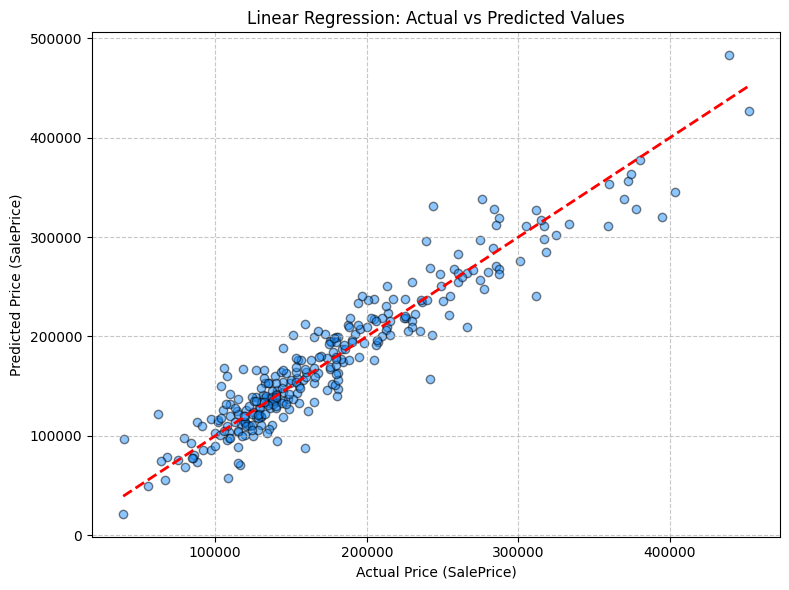

In [21]:
cv_pipeline = make_pipeline(StandardScaler(), LinearRegression())
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_validate(
    cv_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring={
        'rmse': 'neg_root_mean_squared_error',
        'mae': 'neg_mean_absolute_error',
        'r2': 'r2'
    },
    n_jobs=-1
 )

cv_rmse = -cv_scores['test_rmse']
cv_mae = -cv_scores['test_mae']
cv_r2 = cv_scores['test_r2']

print('--- 5-Fold Cross-Validation (Train Set) ---')
print(f'CV RMSE: {cv_rmse.mean():,.2f} ± {cv_rmse.std():,.2f}')
print(f'CV MAE:  {cv_mae.mean():,.2f} ± {cv_mae.std():,.2f}')
print(f'CV R^2:  {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')


lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)


y_pred = lr_model.predict(X_test_scaled)


rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('\n--- Hold-out Test Set Results ---')
print(f'RMSE (Root Mean Squared Error): ${rmse:,.2f}')
print(f'MAE (Mean Absolute Error):      ${mae:,.2f}')
print(f'R^2 (Coefficient of Determination): {r2:.4f}')


plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='dodgerblue', edgecolor='k')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price (SalePrice)')
plt.ylabel('Predicted Price (SalePrice)')
plt.title('Linear Regression: Actual vs Predicted Values')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Sprawdzenie jakości modelu na posczególnych kwartylach

In [22]:

if 'y_pred' not in globals():
    y_pred = lr_model.predict(X_test_scaled)

quartile_bins = pd.qcut(y_test, 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
quartile_rmse = []

for quartile in quartile_bins.cat.categories:
    mask = quartile_bins == quartile
    rmse_q = np.sqrt(mean_squared_error(y_test[mask], y_pred[mask]))
    quartile_rmse.append({
        'Quartile': quartile,
        'Count': int(mask.sum()),
        'RMSE': rmse_q
    })

quartile_rmse_df = pd.DataFrame(quartile_rmse)
print('--- Baseline Linear Regression: RMSE by SalePrice quartile ---')
display(quartile_rmse_df)
print(f"Worst quartile by RMSE: {quartile_rmse_df.loc[quartile_rmse_df['RMSE'].idxmax(), 'Quartile']}")

--- Baseline Linear Regression: RMSE by SalePrice quartile ---


,Quartile,Count,RMSE
0,Q1,76,22227.928023
1,Q2,70,16871.619799
2,Q3,74,21855.666220
3,Q4,72,30740.410302


Worst quartile by RMSE: Q4


## Eksperyment: transformacja targetu (log1p)
Porównanie regresji liniowej trenowanej na `SalePrice` oraz na `log1p(SalePrice)`.
Predykcje z modelu logarytmicznego są odwracane, aby porównywać metryki na oryginalnej skali cen.

,Model,RMSE,MAE,R^2
0,Linear (SalePrice),23471.155619,17339.856408,0.895036
1,Linear (log1p SalePrice),20732.782004,14742.184839,0.918099


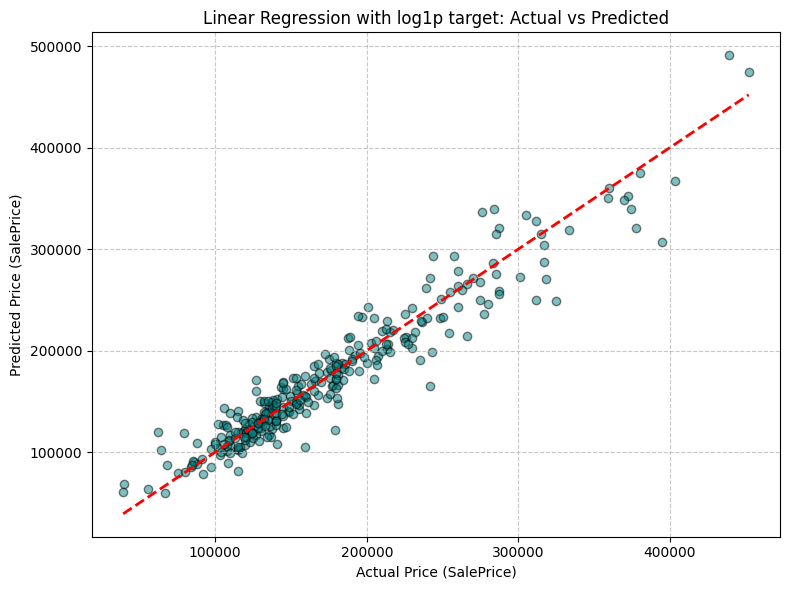

In [23]:
lr_plain = LinearRegression()
lr_plain.fit(X_train_scaled, y_train)
y_pred_plain = lr_plain.predict(X_test_scaled)

rmse_plain = np.sqrt(mean_squared_error(y_test, y_pred_plain))
mae_plain = mean_absolute_error(y_test, y_pred_plain)
r2_plain = r2_score(y_test, y_pred_plain)

y_train_log = np.log1p(y_train)

lr_log = LinearRegression()
lr_log.fit(X_train_scaled, y_train_log)
y_pred_log = lr_log.predict(X_test_scaled)
y_pred_log_inv = np.expm1(y_pred_log)

rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log_inv))
mae_log = mean_absolute_error(y_test, y_pred_log_inv)
r2_log = r2_score(y_test, y_pred_log_inv)

comparison = pd.DataFrame({
    'Model': ['Linear (SalePrice)', 'Linear (log1p SalePrice)'],
    'RMSE': [rmse_plain, rmse_log],
    'MAE': [mae_plain, mae_log],
    'R^2': [r2_plain, r2_log]
})

display(comparison)


plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_log_inv, alpha=0.5, color='teal', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price (SalePrice)')
plt.ylabel('Predicted Price (SalePrice)')
plt.title('Linear Regression with log1p target: Actual vs Predicted')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Regresja Random Forest

In [24]:
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=21)

cv_rf = KFold(n_splits=5, shuffle=True, random_state=21)

rf_cv_scores = cross_validate(
    random_forest_model,
    X_train,
    y_train,
    cv=cv_rf,
    scoring={
        'rmse': 'neg_root_mean_squared_error',
        'mae': 'neg_mean_absolute_error',
        'r2': 'r2'
    },
    n_jobs=-1

)
rf_cv_rmse = -rf_cv_scores['test_rmse']
rf_cv_mae = -rf_cv_scores['test_mae']
rf_cv_r2 = rf_cv_scores['test_r2']

print('--- Random Forest: 5-Fold Cross-Validation (Train Set) ---')
print(f'CV RMSE: {rf_cv_rmse.mean():,.2f} ± {rf_cv_rmse.std():,.2f}')
print(f'CV MAE:  {rf_cv_mae.mean():,.2f} ± {rf_cv_mae.std():,.2f}')
print(f'CV R^2:  {rf_cv_r2.mean():.4f} ± {rf_cv_r2.std():.4f}')

--- Random Forest: 5-Fold Cross-Validation (Train Set) ---
CV RMSE: 26,930.54 ± 3,680.44
CV MAE:  17,037.75 ± 1,997.39
CV R^2:  0.8785 ± 0.0223


In [25]:
random_forest_model.fit(X_train, y_train)
y_pred_rf = random_forest_model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print('--- Random Forest: Hold-out Test Set Results ---')
print(f'RMSE: {rf_rmse:,.2f}')
print(f'MAE:  {rf_mae:,.2f}')
print(f'R^2:  {rf_r2:.4f}')

--- Random Forest: Hold-out Test Set Results ---
RMSE: 22,961.69
MAE:  16,337.33
R^2:  0.8995


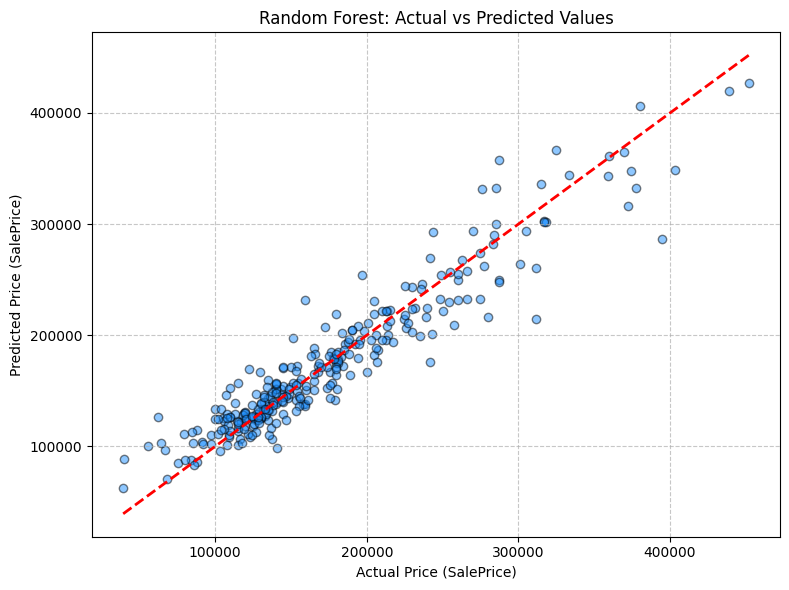

In [26]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_rf, alpha=0.5, color='dodgerblue', edgecolor='k')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--',lw=2)

plt.xlabel('Actual Price (SalePrice)')
plt.ylabel('Predicted Price (SalePrice)')
plt.title('Random Forest: Actual vs Predicted Values')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Random Forest z transformacją targetu `log1p(SalePrice)`   ** kod wygenerowano całkowicie LLM **
Sprawdzenie czy transformacja targetu, która pomogła regresji liniowej, poprawi też wyniki modelu Random Forest.

--- Random Forest: 5-Fold CV (base vs log1p target) ---


,Model,CV RMSE,CV MAE,CV R^2
0,Random Forest (base),"26,930.54 ± 3,680.44","17,037.75 ± 1,997.39",0.8785 ± 0.0223
1,Random Forest (log1p target),"27,730.40 ± 4,081.41","17,408.87 ± 2,365.24",0.8716 ± 0.0241



--- Random Forest: Hold-out (base vs log1p target) ---


,Model,Test RMSE,Test MAE,Test R^2
0,Random Forest (base),22961.691463,16337.327397,0.899543
1,Random Forest (log1p target),24917.281730,16845.528649,0.881703


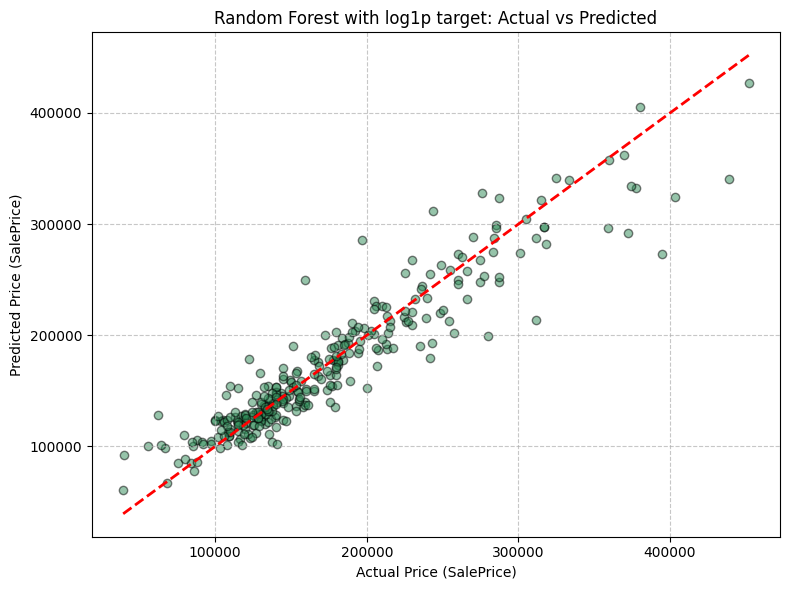

In [27]:
# Random Forest: fair comparison with and without log1p(target) using the same CV folds
cv_rf_log = KFold(n_splits=5, shuffle=True, random_state=21)

rf_base_cv_rmse, rf_base_cv_mae, rf_base_cv_r2 = [], [], []
rf_log_cv_rmse, rf_log_cv_mae, rf_log_cv_r2 = [], [], []

for train_idx, val_idx in cv_rf_log.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Base target
    rf_base_fold = RandomForestRegressor(n_estimators=100, random_state=21)
    rf_base_fold.fit(X_tr, y_tr)
    y_val_pred_base = rf_base_fold.predict(X_val)

    rf_base_cv_rmse.append(np.sqrt(mean_squared_error(y_val, y_val_pred_base)))
    rf_base_cv_mae.append(mean_absolute_error(y_val, y_val_pred_base))
    rf_base_cv_r2.append(r2_score(y_val, y_val_pred_base))

    # log1p target
    rf_log_fold = RandomForestRegressor(n_estimators=100, random_state=21)
    rf_log_fold.fit(X_tr, np.log1p(y_tr))
    y_val_pred_log = rf_log_fold.predict(X_val)
    y_val_pred_log_inv = np.expm1(y_val_pred_log)

    rf_log_cv_rmse.append(np.sqrt(mean_squared_error(y_val, y_val_pred_log_inv)))
    rf_log_cv_mae.append(mean_absolute_error(y_val, y_val_pred_log_inv))
    rf_log_cv_r2.append(r2_score(y_val, y_val_pred_log_inv))

cv_rf_log_comparison = pd.DataFrame({
    'Model': ['Random Forest (base)', 'Random Forest (log1p target)'],
    'CV RMSE': [f"{np.mean(rf_base_cv_rmse):,.2f} ± {np.std(rf_base_cv_rmse):,.2f}", f"{np.mean(rf_log_cv_rmse):,.2f} ± {np.std(rf_log_cv_rmse):,.2f}"],
    'CV MAE': [f"{np.mean(rf_base_cv_mae):,.2f} ± {np.std(rf_base_cv_mae):,.2f}", f"{np.mean(rf_log_cv_mae):,.2f} ± {np.std(rf_log_cv_mae):,.2f}"],
    'CV R^2': [f"{np.mean(rf_base_cv_r2):.4f} ± {np.std(rf_base_cv_r2):.4f}", f"{np.mean(rf_log_cv_r2):.4f} ± {np.std(rf_log_cv_r2):.4f}"]
})

print('--- Random Forest: 5-Fold CV (base vs log1p target) ---')
display(cv_rf_log_comparison)

# Hold-out comparison (kept for consistency with other sections)
y_train_rf_log = np.log1p(y_train)

rf_log_model = RandomForestRegressor(n_estimators=100, random_state=21)
rf_log_model.fit(X_train, y_train_rf_log)

y_pred_rf_log = rf_log_model.predict(X_test)
y_pred_rf_log_inv = np.expm1(y_pred_rf_log)

rf_log_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_log_inv))
rf_log_mae = mean_absolute_error(y_test, y_pred_rf_log_inv)
rf_log_r2 = r2_score(y_test, y_pred_rf_log_inv)

rf_log_comparison = pd.DataFrame({
    'Model': ['Random Forest (base)', 'Random Forest (log1p target)'],
    'Test RMSE': [rf_rmse, rf_log_rmse],
    'Test MAE': [rf_mae, rf_log_mae],
    'Test R^2': [rf_r2, rf_log_r2]
})

print('\n--- Random Forest: Hold-out (base vs log1p target) ---')
display(rf_log_comparison)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf_log_inv, alpha=0.5, color='seagreen', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price (SalePrice)')
plt.ylabel('Predicted Price (SalePrice)')
plt.title('Random Forest with log1p target: Actual vs Predicted')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Regresja XGBoost

In [28]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(n_estimators=100, random_state=21, objective='reg:squarederror')
cv_xgb = KFold(n_splits=5, shuffle=True, random_state=21)
cv_xgb_scores = cross_validate(
    xgb_model, 
    X_train, 
    y_train,
    cv=cv_xgb, 
    scoring= {
        'rmse': 'neg_root_mean_squared_error',
        'mae': 'neg_mean_absolute_error',
        'r2': 'r2'
    },
    n_jobs=-1
)
xgb_cv_rmse = -cv_xgb_scores['test_rmse']
xgb_cv_mae = -cv_xgb_scores['test_mae']
xgb_cv_r2 = cv_xgb_scores['test_r2']

print('--- XGBoost: 5-Fold Cross-Validation (Train Set) ---')
print(f'CV RMSE: {xgb_cv_rmse.mean():,.2f} ± {xgb_cv_rmse.std():,.2f}')
print(f'CV MAE:  {xgb_cv_mae.mean():,.2f} ± {xgb_cv_mae.std():,.2f}')
print(f'CV R^2:  {xgb_cv_r2.mean():.4f} ± {xgb_cv_r2.std():.4f}')

--- XGBoost: 5-Fold Cross-Validation (Train Set) ---
CV RMSE: 27,307.76 ± 2,622.92
CV MAE:  17,737.87 ± 1,218.76
CV R^2:  0.8753 ± 0.0138


In [29]:
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_r2 = r2_score(y_test, y_pred_xgb)

print('--- XGBoost: Hold-out Test Set Results ---')
print(f'RMSE: {xgb_rmse:,.2f}')
print(f'MAE:  {xgb_mae:,.2f}')
print(f'R^2:  {xgb_r2:.4f}')

--- XGBoost: Hold-out Test Set Results ---
RMSE: 24,866.80
MAE:  16,888.02
R^2:  0.8822


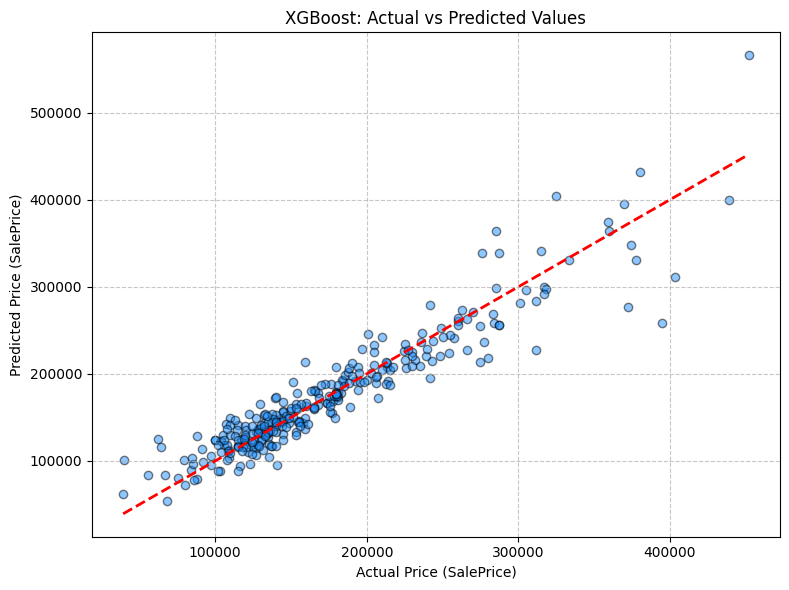

In [30]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.5, color='dodgerblue', edgecolor='k')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price (SalePrice)')
plt.ylabel('Predicted Price (SalePrice)')
plt.title('XGBoost: Actual vs Predicted Values')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Eksperymenty z preprocessingiem 

## 1. Usuwanie prawie stałych kolumn

In [31]:
near_constant_threshold = 0.97

near_constant_cols = []

for col in X.columns:
    top_freq = X[col].value_counts(normalize=True, dropna=False).iloc[0]
    if top_freq >= near_constant_threshold:
        near_constant_cols.append(col)

print("Near-constant columns:")
print(near_constant_cols)
print(f"\nNumber of near-constant columns: {len(near_constant_cols)}")

X_reduced = X.drop(columns=near_constant_cols)

print("Original shape:", X.shape)
print("Reduced shape: ", X_reduced.shape)

Near-constant columns:
['LowQualFinSF', '3SsnPorch', 'PoolArea', 'MSZoning_RH', 'Street_Pave', 'Alley_Pave', 'LotShape_IR2', 'LotShape_IR3', 'LandContour_Low', 'Utilities_NoSeWa', 'LotConfig_FR3', 'LandSlope_Sev', 'Neighborhood_Blueste', 'Neighborhood_BrDale', 'Neighborhood_ClearCr', 'Neighborhood_IDOTRR', 'Neighborhood_MeadowV', 'Neighborhood_NPkVill', 'Neighborhood_NoRidge', 'Neighborhood_SWISU', 'Neighborhood_StoneBr', 'Neighborhood_Timber', 'Neighborhood_Veenker', 'Condition1_PosA', 'Condition1_PosN', 'Condition1_RRAe', 'Condition1_RRAn', 'Condition1_RRNe', 'Condition1_RRNn', 'Condition2_Feedr', 'Condition2_Norm', 'Condition2_PosA', 'Condition2_PosN', 'Condition2_RRAe', 'Condition2_RRAn', 'Condition2_RRNn', 'BldgType_2fmCon', 'BldgType_Twnhs', 'HouseStyle_1.5Unf', 'HouseStyle_2.5Fin', 'HouseStyle_2.5Unf', 'HouseStyle_SFoyer', 'RoofStyle_Gambrel', 'RoofStyle_Mansard', 'RoofStyle_Shed', 'RoofMatl_Membran', 'RoofMatl_Metal', 'RoofMatl_Roll', 'RoofMatl_Tar&Grv', 'RoofMatl_WdShake', 'Ro

In [32]:
X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

scaler_red = StandardScaler()

X_train_red_scaled = scaler_red.fit_transform(X_train_red)
X_test_red_scaled = scaler_red.transform(X_test_red)

X_train_red_scaled = pd.DataFrame(X_train_red_scaled, columns=X_train_red.columns, index=X_train_red.index)
X_test_red_scaled = pd.DataFrame(X_test_red_scaled, columns=X_test_red.columns, index=X_test_red.index)

cv_pipeline_red = make_pipeline(StandardScaler(), LinearRegression())
cv_red = KFold(n_splits=5, shuffle=True, random_state=42)

cv_red_scores = cross_validate(
    cv_pipeline_red,
    X_train_red,
    y_train_red,
    cv=cv_red,
    scoring={
        'rmse': 'neg_root_mean_squared_error',
        'mae': 'neg_mean_absolute_error',
        'r2': 'r2'
    },
    n_jobs=-1
)

cv_red_rmse = -cv_red_scores['test_rmse']
cv_red_mae = -cv_red_scores['test_mae']
cv_red_r2 = cv_red_scores['test_r2']

print('--- Linear Regression after removing near-constant columns: 5-Fold CV ---')
print(f'CV RMSE: {cv_red_rmse.mean():,.2f} ± {cv_red_rmse.std():,.2f}')
print(f'CV MAE:  {cv_red_mae.mean():,.2f} ± {cv_red_mae.std():,.2f}')
print(f'CV R^2:  {cv_red_r2.mean():.4f} ± {cv_red_r2.std():.4f}')

--- Linear Regression after removing near-constant columns: 5-Fold CV ---
CV RMSE: 26,335.93 ± 2,568.77
CV MAE:  18,049.59 ± 669.41
CV R^2:  0.8833 ± 0.0117


In [33]:
lr_red_model = LinearRegression()
lr_red_model.fit(X_train_red_scaled, y_train_red)

y_pred_red = lr_red_model.predict(X_test_red_scaled)

rmse_red = np.sqrt(mean_squared_error(y_test_red, y_pred_red))
mae_red = mean_absolute_error(y_test_red, y_pred_red)
r2_red = r2_score(y_test_red, y_pred_red)

print('\n--- Hold-out Test Set Results ---')
print(f'RMSE: {rmse_red:,.2f}')
print(f'MAE:  {mae_red:,.2f}')
print(f'R^2:  {r2_red:.4f}')


--- Hold-out Test Set Results ---
RMSE: 23,588.46
MAE:  17,472.24
R^2:  0.8940


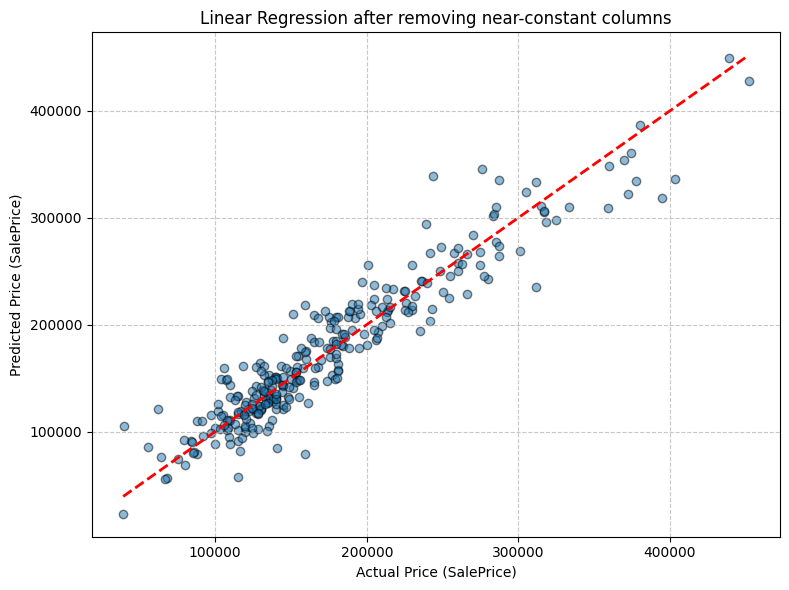

In [34]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_red, y_pred_red, alpha=0.5, edgecolor='k')

plt.plot(
    [y_test_red.min(), y_test_red.max()],
    [y_test_red.min(), y_test_red.max()],
    'r--',
    lw=2
)

plt.xlabel('Actual Price (SalePrice)')
plt.ylabel('Predicted Price (SalePrice)')
plt.title('Linear Regression after removing near-constant columns')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Usuwanie jednej z cech skorelowanej pary 

In [35]:
corr_threshold = 0.9

corr_matrix = X.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

cols_to_drop_corr = [
    col for col in upper_triangle.columns
    if any(upper_triangle[col] > corr_threshold)
]

print("Columns to drop because of high correlation:")
print(cols_to_drop_corr)
print(f"\nNumber of columns to drop: {len(cols_to_drop_corr)}")

X_corr_reduced = X.drop(columns=cols_to_drop_corr)

print("\nOriginal shape:", X.shape)
print("Reduced shape: ", X_corr_reduced.shape)


X_train_corr, X_test_corr, y_train_corr, y_test_corr = train_test_split(
    X_corr_reduced, y, test_size=0.2, random_state=42
)


cv_pipeline_corr = make_pipeline(StandardScaler(), LinearRegression())
cv_corr = KFold(n_splits=5, shuffle=True, random_state=42)

cv_corr_scores = cross_validate(
    cv_pipeline_corr,
    X_train_corr,
    y_train_corr,
    cv=cv_corr,
    scoring={
        'rmse': 'neg_root_mean_squared_error',
        'mae': 'neg_mean_absolute_error',
        'r2': 'r2'
    },
    n_jobs=-1
)

cv_corr_rmse = -cv_corr_scores['test_rmse']
cv_corr_mae = -cv_corr_scores['test_mae']
cv_corr_r2 = cv_corr_scores['test_r2']

print('\n--- Linear Regression after removing highly correlated columns: 5-Fold CV ---')
print(f'CV RMSE: {cv_corr_rmse.mean():,.2f} ± {cv_corr_rmse.std():,.2f}')
print(f'CV MAE:  {cv_corr_mae.mean():,.2f} ± {cv_corr_mae.std():,.2f}')
print(f'CV R^2:  {cv_corr_r2.mean():.4f} ± {cv_corr_r2.std():.4f}')

scaler_corr = StandardScaler()
X_train_corr_scaled = scaler_corr.fit_transform(X_train_corr)
X_test_corr_scaled = scaler_corr.transform(X_test_corr)

lr_corr_model = LinearRegression()
lr_corr_model.fit(X_train_corr_scaled, y_train_corr)

y_pred_corr = lr_corr_model.predict(X_test_corr_scaled)

rmse_corr = np.sqrt(mean_squared_error(y_test_corr, y_pred_corr))
mae_corr = mean_absolute_error(y_test_corr, y_pred_corr)
r2_corr = r2_score(y_test_corr, y_pred_corr)

print('\n--- Hold-out Test Set Results ---')
print(f'RMSE: {rmse_corr:,.2f}')
print(f'MAE:  {mae_corr:,.2f}')
print(f'R^2:  {r2_corr:.4f}')

Columns to drop because of high correlation:
['GarageCond', 'RoofStyle_Hip', 'Exterior2nd_CBlock', 'Exterior2nd_CmentBd', 'Exterior2nd_MetalSd', 'Exterior2nd_VinylSd', 'BsmtFinType1_None', 'BsmtFinType2_None', 'GarageType_None', 'GarageFinish_None', 'PoolQC_None', 'MiscFeature_Shed', 'SaleCondition_Partial']

Number of columns to drop: 13

Original shape: (1456, 230)
Reduced shape:  (1456, 217)

--- Linear Regression after removing highly correlated columns: 5-Fold CV ---
CV RMSE: 27,922.86 ± 2,263.75
CV MAE:  19,139.69 ± 976.08
CV R^2:  0.8667 ± 0.0256

--- Hold-out Test Set Results ---
RMSE: 23,589.82
MAE:  17,280.95
R^2:  0.8940


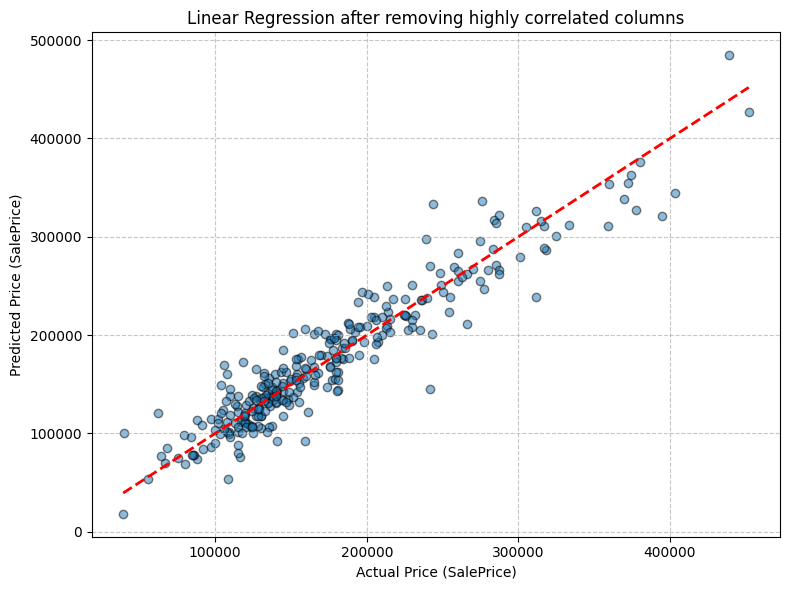

In [36]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_corr, y_pred_corr, alpha=0.5, edgecolor='k')

plt.plot(
    [y_test_corr.min(), y_test_corr.max()],
    [y_test_corr.min(), y_test_corr.max()],
    'r--',
    lw=2
)

plt.xlabel('Actual Price (SalePrice)')
plt.ylabel('Predicted Price (SalePrice)')
plt.title('Linear Regression after removing highly correlated columns')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Feature engineering 
Dodanie ręcznie zaprojektowanych cech. 

Added engineered features:
['HouseAge', 'RemodAge', 'HasGarage', 'HasBasement']

--- Linear Regression + Feature Engineering: 5-Fold CV ---
CV RMSE: 28,026.68 ± 2,266.43
CV MAE:  19,123.66 ± 1,040.09
CV R^2:  0.8656 ± 0.0265

--- Hold-out Test Set Results (Feature Engineering) ---
RMSE: 23,448.24
MAE:  17,327.24
R^2:  0.8952

Comparison with baseline model:


,Model,Test RMSE,Test MAE,Test R^2
0,Linear Regression (base),23471.155619,17339.856408,0.895036
1,Linear Regression + Feature Engineering,23448.241099,17327.238509,0.895241


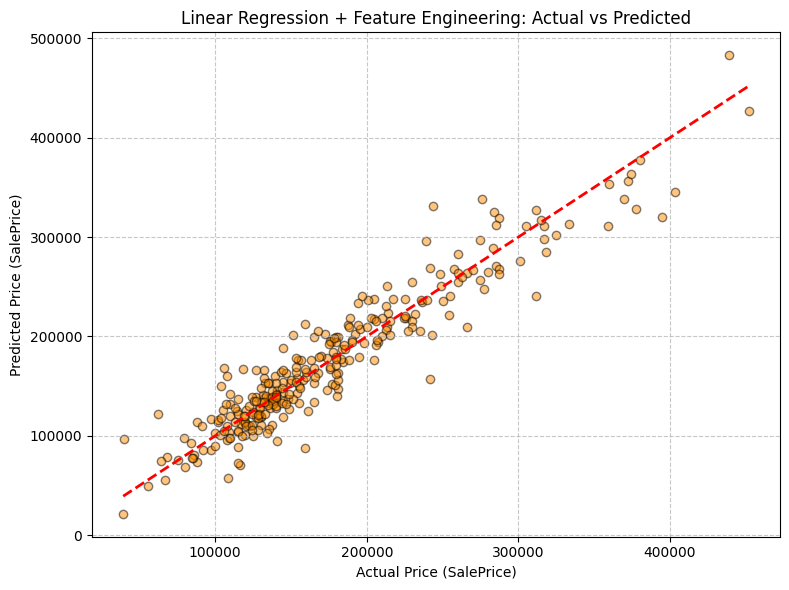

In [37]:
X_fe = X.copy()

X_fe['HouseAge'] = (X_fe['YrSold'] - X_fe['YearBuilt']).clip(lower=0)
X_fe['RemodAge'] = (X_fe['YrSold'] - X_fe['YearRemodAdd']).clip(lower=0)

X_fe['HasGarage'] = (X_fe['GarageCars'] > 0).astype(int)
X_fe['HasBasement'] = (X_fe['TotalBsmtSF'] > 0).astype(int)

new_features = ['HouseAge', 'RemodAge', 'HasGarage', 'HasBasement']
print('Added engineered features:')
print(new_features)

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y, test_size=0.2, random_state=42
)

cv_pipeline_fe = make_pipeline(StandardScaler(), LinearRegression())
cv_fe = KFold(n_splits=5, shuffle=True, random_state=42)

cv_fe_scores = cross_validate(
    cv_pipeline_fe,
    X_train_fe,
    y_train_fe,
    cv=cv_fe,
    scoring={
        'rmse': 'neg_root_mean_squared_error',
        'mae': 'neg_mean_absolute_error',
        'r2': 'r2'
    },
    n_jobs=-1
)

cv_fe_rmse = -cv_fe_scores['test_rmse']
cv_fe_mae = -cv_fe_scores['test_mae']
cv_fe_r2 = cv_fe_scores['test_r2']

print('\n--- Linear Regression + Feature Engineering: 5-Fold CV ---')
print(f'CV RMSE: {cv_fe_rmse.mean():,.2f} ± {cv_fe_rmse.std():,.2f}')
print(f'CV MAE:  {cv_fe_mae.mean():,.2f} ± {cv_fe_mae.std():,.2f}')
print(f'CV R^2:  {cv_fe_r2.mean():.4f} ± {cv_fe_r2.std():.4f}')

scaler_fe = StandardScaler()
X_train_fe_scaled = scaler_fe.fit_transform(X_train_fe)
X_test_fe_scaled = scaler_fe.transform(X_test_fe)

lr_fe_model = LinearRegression()
lr_fe_model.fit(X_train_fe_scaled, y_train_fe)
y_pred_fe = lr_fe_model.predict(X_test_fe_scaled)

rmse_fe = np.sqrt(mean_squared_error(y_test_fe, y_pred_fe))
mae_fe = mean_absolute_error(y_test_fe, y_pred_fe)
r2_fe = r2_score(y_test_fe, y_pred_fe)

print('\n--- Hold-out Test Set Results (Feature Engineering) ---')
print(f'RMSE: {rmse_fe:,.2f}')
print(f'MAE:  {mae_fe:,.2f}')
print(f'R^2:  {r2_fe:.4f}')

fe_comparison = pd.DataFrame({
    'Model': ['Linear Regression (base)', 'Linear Regression + Feature Engineering'],
    'Test RMSE': [rmse, rmse_fe],
    'Test MAE': [mae, mae_fe],
    'Test R^2': [r2, r2_fe]
})

print('\nComparison with baseline model:')
display(fe_comparison)

plt.figure(figsize=(8, 6))
plt.scatter(y_test_fe, y_pred_fe, alpha=0.5, color='darkorange', edgecolor='k')
plt.plot([y_test_fe.min(), y_test_fe.max()], [y_test_fe.min(), y_test_fe.max()], 'r--', lw=2)
plt.xlabel('Actual Price (SalePrice)')
plt.ylabel('Predicted Price (SalePrice)')
plt.title('Linear Regression + Feature Engineering: Actual vs Predicted')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Ensembling (Linear + Linear log-target + Random Forest)
Łączenie predykcji trzech modeli przez ważoną średnią. Wagi są strojone na walidacji, a wynik końcowy raportowany na hold-out test set.

In [39]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Make the section runnable independently.
if 'X' not in globals() or 'y' not in globals():
    if 'df' in globals():
        if 'SalePrice' not in df.columns:
            raise ValueError("Brak kolumny 'SalePrice' w df.")
        X = df.drop(columns=['SalePrice', 'Id']) if 'Id' in df.columns else df.drop(columns=['SalePrice'])
        y = df['SalePrice']
        print("X i y nie były zdefiniowane - utworzono je z df.")
    else:
        raise NameError(
            "Brak X/y i df. Uruchom wcześniejsze komórki przygotowania danych przed sekcją ensemblingu."
        )

# Train/validation/test split: validation is used only for weight tuning.
X_train_full, X_test_ens, y_train_full, y_test_ens = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train_ens, X_val_ens, y_train_ens, y_val_ens = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

scaler_ens = StandardScaler()
X_train_ens_scaled = scaler_ens.fit_transform(X_train_ens)
X_val_ens_scaled = scaler_ens.transform(X_val_ens)
X_test_ens_scaled = scaler_ens.transform(X_test_ens)

# 1) Linear regression on original target
lr_ens = LinearRegression()
lr_ens.fit(X_train_ens_scaled, y_train_ens)
pred_val_lr = lr_ens.predict(X_val_ens_scaled)
pred_test_lr = lr_ens.predict(X_test_ens_scaled)

# 2) Linear regression on log1p(target)
lr_log_ens = LinearRegression()
lr_log_ens.fit(X_train_ens_scaled, np.log1p(y_train_ens))
pred_val_lr_log = np.expm1(lr_log_ens.predict(X_val_ens_scaled))
pred_test_lr_log = np.expm1(lr_log_ens.predict(X_test_ens_scaled))

# 3) Random Forest
rf_ens = RandomForestRegressor(n_estimators=300, random_state=21, n_jobs=-1)
rf_ens.fit(X_train_ens, y_train_ens)
pred_val_rf = rf_ens.predict(X_val_ens)
pred_test_rf = rf_ens.predict(X_test_ens)

# Tune ensemble weights on validation set by grid search.
best_rmse = float('inf')
best_weights = None

for w_lr in np.arange(0.0, 1.01, 0.05):
    for w_lr_log in np.arange(0.0, 1.01 - w_lr, 0.05):
        w_rf = 1.0 - w_lr - w_lr_log
        if w_rf < 0:
            continue

        pred_val_ens = (
            w_lr * pred_val_lr +
            w_lr_log * pred_val_lr_log +
            w_rf * pred_val_rf
        )

        rmse_val = np.sqrt(mean_squared_error(y_val_ens, pred_val_ens))
        if rmse_val < best_rmse:
            best_rmse = rmse_val
            best_weights = (w_lr, w_lr_log, w_rf)

w_lr_best, w_lr_log_best, w_rf_best = best_weights
print('Best weights found on validation set:')
print(f'LR={w_lr_best:.2f}, LR_log={w_lr_log_best:.2f}, RF={w_rf_best:.2f}')
print(f'Validation RMSE (best ensemble): {best_rmse:,.2f}')

# Final test predictions using tuned weights.
pred_test_ens = (
    w_lr_best * pred_test_lr +
    w_lr_log_best * pred_test_lr_log +
    w_rf_best * pred_test_rf
)

rmse_lr = np.sqrt(mean_squared_error(y_test_ens, pred_test_lr))
rmse_lr_log = np.sqrt(mean_squared_error(y_test_ens, pred_test_lr_log))
rmse_rf = np.sqrt(mean_squared_error(y_test_ens, pred_test_rf))
rmse_ens = np.sqrt(mean_squared_error(y_test_ens, pred_test_ens))

mae_ens = mean_absolute_error(y_test_ens, pred_test_ens)
r2_ens = r2_score(y_test_ens, pred_test_ens)

ensemble_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Linear Regression (log1p target)',
        'Random Forest',
        f'Weighted Ensemble (LR={w_lr_best:.2f}, LR_log={w_lr_log_best:.2f}, RF={w_rf_best:.2f})'
    ],
    'Test RMSE': [rmse_lr, rmse_lr_log, rmse_rf, rmse_ens]
}).sort_values('Test RMSE').reset_index(drop=True)

print('\n--- Test RMSE Comparison ---')
display(ensemble_comparison)

print('--- Ensemble Hold-out Test Metrics ---')
print(f'RMSE: {rmse_ens:,.2f}')
print(f'MAE:  {mae_ens:,.2f}')
print(f'R^2:  {r2_ens:.4f}')

Best weights found on validation set:
LR=0.00, LR_log=0.60, RF=0.40
Validation RMSE (best ensemble): 22,835.97

--- Test RMSE Comparison ---


,Model,Test RMSE
0,"Weighted Ensemble (LR=0.00, LR_log=0.60, RF=0.40)",20006.231230
1,Linear Regression (log1p target),22434.929925
2,Random Forest,23637.547307
3,Linear Regression,25846.254158


--- Ensemble Hold-out Test Metrics ---
RMSE: 20,006.23
MAE:  13,749.34
R^2:  0.9237
